In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gsw as seawater
from shapely.geometry import Polygon
import dask
import seaborn as sns
import glob
import dask.distributed
import dask_jobqueue
import warnings

from scipy.stats import bootstrap

warnings.filterwarnings("ignore")

In [36]:
cluster = dask_jobqueue.SLURMCluster(
    # Dask worker size
    cores=4,
    memory="16GB",
    processes=1,  # Dask workers per job
    # SLURM job script things
    queue="base",
    walltime="12:00:00",
    # Dask worker network and temporary storage
    interface="ib0",
    local_directory="$TMPDIR",  # for spilling tmp data to disk
    log_directory="slurm/",
)

client = dask.distributed.Client(cluster)

cluster.scale(jobs=15)  # 15
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.18.4.22:8787/status,
Dashboard: http://172.18.4.22:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.22:42819,Workers: 0
Dashboard: http://172.18.4.22:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
# converting the age from nano seconds
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)

mesh_mask = xr.open_dataset(inpath + "mesh_masks/mesh_mask.nc")
mesh_hzgr = xr.open_dataset(inpath + "mesh_masks/mesh_hzgr.nc")
mesh_hgr = xr.open_dataset(inpath + "mesh_masks/mesh_hgr.nc")

z = mesh_hzgr.e3t_0
t_mask = mesh_mask.tmask

# bathymetry (Depth level) at every grid point
bathymetry = (
    (z * t_mask)
    .isel(t=0)
    .sum(dim="z")
    .assign_coords({"nav_lat": mesh_hgr.nav_lat, "nav_lon": mesh_hgr.nav_lon})
)

# turn zeros into nans, easier to see where continents are
bath_total_nans = bathymetry.where(bathymetry != 0)
land_mask = mesh_mask.tmask.where(mesh_mask.tmask != 0).isel(t=0, z=0)


def create_polygon(vertices):
    polygon = Polygon(vertices)
    x_coords, y_coords = polygon.exterior.xy
    return polygon, x_coords, y_coords


vertices_Gsea = [(-12, 74.5), (-2.5, 76.7), (4, 74), (-1, 73), (-12, 73), (-12, 74.5)]

vertices_Lofoten = [
    (-4.5, 70.7),
    (2, 68.6),
    (9, 68.6),
    (14, 69.6),
    (6, 72.5),
    (-4.5, 70.7),
]

vertices_Iceland = [(-13.5, 70), (-9.2, 70), (-9.2, 67.5), (-13.5, 67.5)]

vertices_Norwegian = [
    (-6.2, 64),
    (-6.2, 69.5),
    (-3, 69.5),
    (1, 67.5),
    (1, 64),
    (-6.2, 64),
]


# Create polygons and extract coordinates
polygon_Gsea, x_GSea, y_GSea = create_polygon(vertices_Gsea)
polygon_Lofoten, x_Lofoten, y_Lofoten = create_polygon(vertices_Lofoten)
polygon_Iceland, x_Iceland, y_Iceland = create_polygon(vertices_Iceland)
polygon_Norwegian, x_Norwegian, y_Norwegian = create_polygon(vertices_Norwegian)

## Figure S1

In [29]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
S = xr.open_dataset(inpath + "S_section.nc")
S_2021_2024 = xr.open_dataset(inpath + "S_section_2021_2024.nc")

S = xr.concat([S, S_2021_2024], dim="time_counter")

T1 shape: (50, 57)
S1 shape: (50, 57)
Q1 shape: (50, 57)

T range: -0.5542136430740356 to 8.80672836303711
S range: 34.88362121582031 to 35.304039001464844
Q range (Sv): 33.481446481146214 Sv total


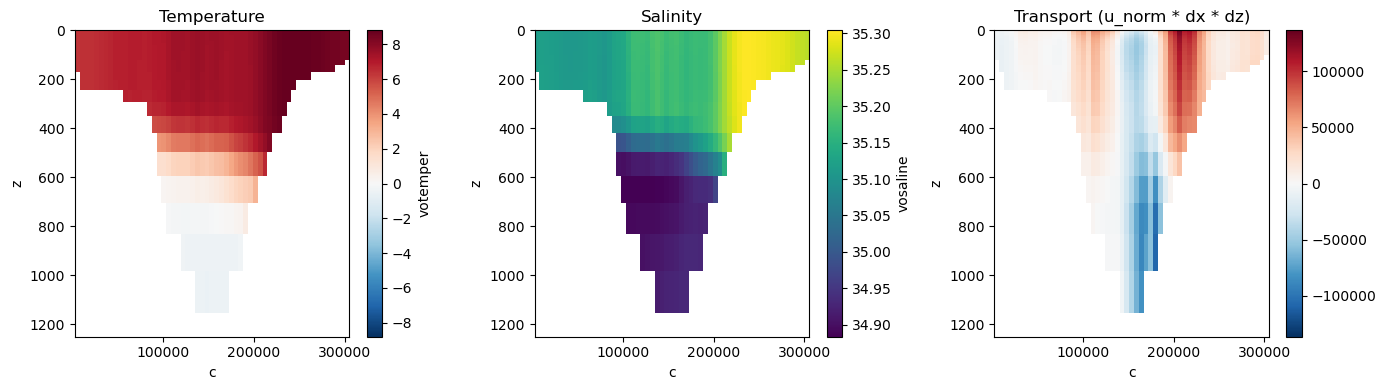

In [30]:
T1 = S.votemper.isel(time_counter=0)
S1 = S.vosaline.isel(time_counter=0)
Q1 = (-S.u_rot_normal * S.dx * S.dz).isel(time_counter=0)

print("T1 shape:", T1.shape)
print("S1 shape:", S1.shape)
print("Q1 shape:", Q1.shape)

print("\nT range:", float(T1.min()), "to", float(T1.max()))
print("S range:", float(S1.min()), "to", float(S1.max()))
print("Q range (Sv):", float(Q1.sum()) / 1e6, "Sv total")  # sanity check — FSC ~2 Sv

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

T1.plot(ax=axes[0], cmap="RdBu_r", yincrease=False)
axes[0].set_title("Temperature")

S1.plot(ax=axes[1], cmap="viridis", yincrease=False)
axes[1].set_title("Salinity")

Q1.plot(ax=axes[2], cmap="RdBu_r", yincrease=False)
axes[2].set_title("Transport (u_norm * dx * dz)")

for ax in axes:
    ax.set_ylim(0, 1250)
    ax.invert_yaxis()  # depth should increase downwards
plt.tight_layout()
plt.show()

In [31]:
plt.rcParams.update({"font.size": 12})

Global T range: -1.41 to 14.67
Global S range: 34.7476 to 35.5234


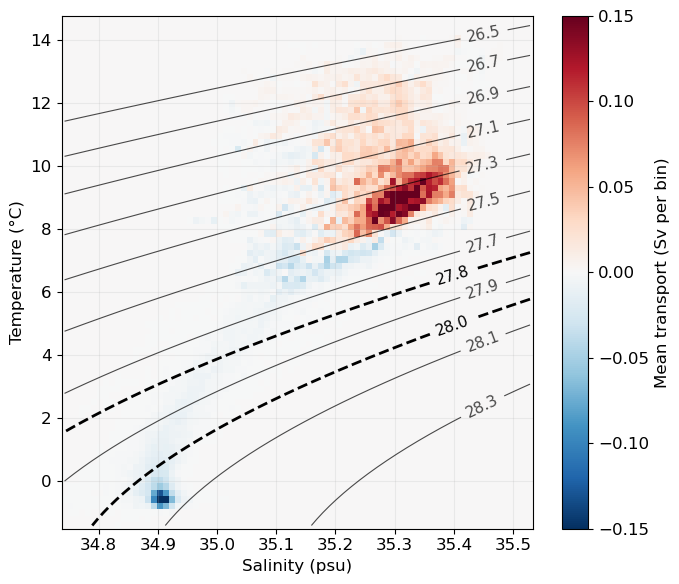

In [ ]:
## NO CLIPPING VERSION (bins cover full data range, so no need to clip)

# --- Find global T and S range across ALL time steps ---
n_times = S.dims["time_counter"]
T_all, S_all = [], []
for t in range(n_times):
    T_all.append(S.votemper.isel(time_counter=t).values.ravel())
    S_all.append(S.vosaline.isel(time_counter=t).values.ravel())

T_all = np.concatenate(T_all)
S_all = np.concatenate(S_all)

T_min, T_max = np.nanmin(T_all), np.nanmax(T_all)
S_min, S_max = np.nanmin(S_all), np.nanmax(S_all)
print(f"Global T range: {T_min:.2f} to {T_max:.2f}")
print(f"Global S range: {S_min:.4f} to {S_max:.4f}")

# --- Bin edges from global range (no clipping) ---
T_bins = np.linspace(T_min - 0.1, T_max + 0.1, 80)
S_bins = np.linspace(S_min - 0.01, S_max + 0.01, 80)
T_centres = 0.5 * (T_bins[:-1] + T_bins[1:])
S_centres = 0.5 * (S_bins[:-1] + S_bins[1:])

transport_TS = np.zeros((len(S_bins) - 1, len(T_bins) - 1))  # (S, T)

# --- Loop over all time steps ---
for t in range(n_times):
    T_flat = S.votemper.isel(time_counter=t).values.ravel()
    S_flat = S.vosaline.isel(time_counter=t).values.ravel()
    Q_flat = (-S.u_rot_normal * S.dx * S.dz).isel(
        time_counter=t
    ).values.ravel() / 1e6  # Sv

    mask = np.isfinite(T_flat) & np.isfinite(S_flat) & np.isfinite(Q_flat)
    H, _, _ = np.histogram2d(
        S_flat[mask], T_flat[mask], bins=[S_bins, T_bins], weights=Q_flat[mask]
    )
    transport_TS += H

transport_TS /= n_times  # time-mean [Sv per bin]

# --- Density contours ---
SS, TT = np.meshgrid(S_centres, T_centres)

p_ref = 0  # surface reference
lon_ref, lat_ref = -6.0, 61.0  # approximate FSC location

# be careful since S and T is in eos80 i.e. psu and potential temperature
SA = seawater.SA_from_SP(SS, p_ref, lon_ref, lat_ref)  # PSU → Absolute Salinity
CT = seawater.CT_from_pt(SA, TT)  # pot. temp → Conservative Temp
sigma0 = seawater.sigma0(SA, CT)


# --- Plot ---
# vmax = np.nanpercentile(np.abs(transport_TS), 99)
# norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(
    S_centres,
    T_centres,
    transport_TS.T,
    cmap="RdBu_r",
    vmin=-0.15,
    vmax=0.15,
    shading="auto",
)  # norm=norm,
cbar = plt.colorbar(pcm, ax=ax, label="Mean transport (Sv per bin)")

# Density contours
# density_levels = np.arange(26.5, 28.5, 0.2)
# cs = ax.contour(S_centres, T_centres, sigma0,
#                 levels=density_levels, colors='k', linewidths=0.8, alpha=0.7)
# ax.clabel(cs, fmt='%.1f', fontsize=10, inline=True, inline_spacing=5)


density_levels = np.arange(26.5, 28.5, 0.2)
cs = ax.contour(
    S_centres,
    T_centres,
    sigma0,
    levels=density_levels,
    colors="k",
    linewidths=0.8,
    alpha=0.7,
)

# Single salinity column — all labels stack vertically
S_label = 35.45  # right edge, away from data cloud — adjust as needed

manual_positions = []
for level in density_levels:
    S_idx = np.argmin(np.abs(S_centres - S_label))
    T_col = sigma0[:, S_idx]
    T_idx = np.argmin(np.abs(T_col - level))
    manual_positions.append((S_label, T_centres[T_idx]))

ax.clabel(cs, fmt="%.1f", fontsize=11, manual=manual_positions, inline=True)


# Overflow threshold
cs = ax.contour(
    S_centres,
    T_centres,
    sigma0,
    levels=[27.8, 28.0],
    colors="k",
    linewidths=2,
    linestyles="--",
)
ax.clabel(cs, fmt="%.1f", fontsize=11, inline=True)

ax.set_xlabel("Salinity (psu)")
ax.set_ylabel("Temperature (°C)")
# ax.set_title('T-S transport diagram a Section S')
ax.grid(True, alpha=0.2)
plt.tight_layout()
# plt.savefig('S1.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure S2

In [37]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/data/level2_uniform_release_clim_land_nans/"

ds = xr.open_mfdataset(
    sorted(
        glob.glob(
            inpath + "density_filtered_uniform_parcels_release_2000-2020_chunk_*.zarr"
        )
    ),
    engine="zarr",
    chunks="auto",
    combine="nested",
    concat_dim="trajectory",
)

# Reset trajectory index to clean 0, 1, 2, ...N
ds["trajectory"] = np.arange(ds.trajectory.size)
# print(ds)

# Just use ds directly for analysis — no need to save combined
ds = ds.chunk({"trajectory": 2_000, "obs": -1})

# =========================
# Domain exit definition
# =========================
# ORIGINALLY USED
# exited = (ds['lat'] >= 84) | (ds['lon'] >= 18)
# ever_exits = exited.any(dim='obs')

exited = (ds["lat"] >= 81) | (ds["lat"] <= 59) | (ds["lon"] >= 18) | (ds["lon"] <= -25)
ever_exits = exited.any(dim="obs")

# Compute only what's needed — small boolean arrays
print("Computing exit masks...")
ever_exits_computed = ever_exits.compute()
# starts_outside = ((ds['lat'].isel(obs=0) >= 84) | (ds['lon'].isel(obs=0) >= 18)).compute()

# print(f"Particles starting outside domain: {starts_outside.sum().values}")
print(f"Particles that ever exit: {ever_exits_computed.sum().values}")
print(f"Particles that never exit: {(~ever_exits_computed).sum().values}")

Computing exit masks...
Particles that ever exit: 9788355
Particles that never exit: 4907824


In [39]:
n_total = int(ds.trajectory.size)
n_exiters = int(ever_exits_computed.sum().values)

# =========================
# Age at exit — stay lazy, avoid .values on full array
# =========================
print("Computing age at exit...")

# Get age only for exiters — much smaller array
first_exit_obs = exited.argmax(dim="obs").where(ever_exits_computed)

first_exit_obs = first_exit_obs.compute()

age_at_exit = ds["age"].isel(obs=first_exit_obs.fillna(0).astype(int))
age_at_exit_years = -age_at_exit.where(ever_exits_computed) * hours_to_years

# Compute only the exit ages, not the full trajectory array
age_at_exit_years_computed = age_at_exit_years.compute()

age_values = age_at_exit_years_computed.values[
    ~np.isnan(age_at_exit_years_computed.values)
]

Computing age at exit...


In [40]:
# 1D read only — instant
release_year = ds["time"].isel(obs=0).compute().dt.year.values

# For non-exiters only
non_exiter_release = release_year[~ever_exits_computed.values]

# Max possible backtrack = years since GLORYS12 start (1993), capped at 10
max_possible_backtrack = np.minimum(non_exiter_release - 1993, 10.0)

# Proxy for age_of_non_exiters — how long they COULD have been tracked
age_of_non_exiters = max_possible_backtrack.astype(float)

# Hit data limit = couldn't backtrack full 10yr due to data boundary
hit_data_limit = max_possible_backtrack < 9.5
genuine_non_exiters = ~hit_data_limit

In [41]:
# =========================
# Save all 1D results to netCDF
# =========================

# Build a full-length (n_total) array for hit_data_limit and age_of_non_exiters
# so they align with trajectory dimension — NaN/False for exiters
hit_data_limit_full = np.full(n_total, False)
age_of_non_exiters_full = np.full(n_total, np.nan)
hit_data_limit_full[~ever_exits_computed.values] = hit_data_limit
age_of_non_exiters_full[~ever_exits_computed.values] = age_of_non_exiters

ds_exit = xr.Dataset(
    {
        # Boolean: did this trajectory ever exit?
        "ever_exits": ever_exits_computed,
        # Age at exit in years — NaN for non-exiters
        "age_at_exit_years": age_at_exit_years_computed,
        # First obs index where trajectory exited — NaN for non-exiters
        "first_exit_obs": first_exit_obs,
        # Release year for each trajectory
        "release_year": xr.DataArray(release_year, dims="trajectory"),
        # Max possible backtrack duration — NaN for exiters
        "age_of_non_exiters": xr.DataArray(age_of_non_exiters_full, dims="trajectory"),
        # Hit data limit — False for exiters
        "hit_data_limit": xr.DataArray(hit_data_limit_full, dims="trajectory"),
    }
)

# ds_exit.to_netcdf('exit_statistics_full_expt_adjusted_bounds.nc')

In [42]:
## FROM DIFFERENT BOUNDARIES

# =========================
# Exit statistics — all pure numpy, no dask
# =========================
#
# Key variables:
# ┌─────────────────────┬──────────────────────────────────────────────────────────────┐
# │ Variable            │ What it is                                                   │
# ├─────────────────────┼──────────────────────────────────────────────────────────────┤
# │ age_values          │ Exit age (years) for particles that exited — 1D, ~5M values  │
# │                     │ i.e. how far back in time they were when they crossed 84°N   │
# │                     │ or 18°E. Only defined for exiters.                           │
# ├─────────────────────┼──────────────────────────────────────────────────────────────┤
# │ age_of_non_exiters  │ Max backtrack duration for non-exiters — 1D, ~9M values      │
# │                     │ i.e. how far back in time they were tracked before the       │
# │                     │ simulation ended. NOT an exit age — these never exited.      │
# ├─────────────────────┼──────────────────────────────────────────────────────────────┤
# │ hit_data_limit      │ Boolean mask of non-exiters tracked >=9.5yr — these ran out  │
# │                     │ of GLORYS12 data. Would likely have exited given more data.  │
# ├─────────────────────┼──────────────────────────────────────────────────────────────┤
# │ genuine_non_exiters │ Boolean mask of non-exiters tracked <9.5yr — these truly     │
# │                     │ recirculated within the Nordic Seas for the full window.     │
# └─────────────────────┴──────────────────────────────────────────────────────────────┘

print("=" * 55)
print("TOTAL PARTICLES")
print("=" * 55)
print(f"  Total:      {n_total:,}")
print(f"  Ever exit:  {n_exiters:,} ({n_exiters/n_total*100:.1f}%)")
print(f"  Never exit: {n_total - n_exiters:,} ({(n_total-n_exiters)/n_total*100:.1f}%)")

print("\n" + "=" * 55)
print("EXIT TIMING — cumulative % of ALL particles")
print("=" * 55)
for threshold in [5, 7, 10, 15, 20, 27]:
    pct_of_total = (age_values <= threshold).sum() / n_total * 100
    pct_of_exiters = (age_values <= threshold).sum() / n_exiters * 100
    print(
        f"  Within {threshold:>2} yr: {pct_of_total:.1f}% of all | {pct_of_exiters:.1f}% of exiters"
    )

print("\n" + "=" * 55)
print("EXIT AGE DISTRIBUTION (exiters only)")
print("  = age_values statistics")
print("=" * 55)
print(f"  Mean:   {age_values.mean():.1f} yr")
print(f"  Median: {np.median(age_values):.1f} yr")
print(f"  Std:    {age_values.std():.1f} yr")
for p in [25, 75, 90, 95]:
    print(f"  {p}th percentile: {np.percentile(age_values, p):.1f} yr")

# =========================
# Key statistics — pure numpy, fast
# =========================
print("\n--- Exit statistics ---")
print(f"Total particles:     {n_total:,}")
print(f"Ever exit domain:    {n_exiters:,} ({n_exiters/n_total*100:.1f}%)")
print(
    f"Never exit:          {n_total - n_exiters:,} ({(n_total-n_exiters)/n_total*100:.1f}%)"
)

for threshold in [5, 7, 10, 15, 20]:
    pct_of_total = (age_values <= threshold).sum() / n_total * 100
    pct_of_exiters = (age_values <= threshold).sum() / n_exiters * 100
    print(
        f"{threshold:>2} years: {pct_of_total:.1f}% of all | {pct_of_exiters:.1f}% of exiters"
    )


print("\n" + "=" * 55)
print("NON-EXITER DIAGNOSIS")
print("  = age_of_non_exiters + hit_data_limit + genuine_non_exiters")
print("=" * 55)
n_non = len(age_of_non_exiters)
print(f"  Total non-exiters:        {n_non:,} ({n_non/n_total*100:.1f}% of all)")
print(f"  Mean backtrack duration:  {age_of_non_exiters.mean():.1f} yr")
print(f"  Max backtrack duration:   {age_of_non_exiters.max():.1f} yr")
print()
print(
    f"  Hit data limit (>=9.5yr): {hit_data_limit.sum():,} ({hit_data_limit.sum()/n_total*100:.1f}% of all)"
)
print(
    f"  Genuine non-exiters:      {(~hit_data_limit).sum():,} ({(~hit_data_limit).sum()/n_total*100:.1f}% of all)"
)

print("\n" + "=" * 55)
print("FULL BREAKDOWN (should sum to 100%)")
print("=" * 55)
exit_le10 = (age_values <= 10).sum() / n_total * 100
exit_gt10 = (age_values > 10).sum() / n_total * 100
data_lim = hit_data_limit.sum() / n_total * 100
genuine = (~hit_data_limit).sum() / n_total * 100
print(f"  Exit within 10yr:  {exit_le10:.1f}%")
print(f"  Exit after  10yr:  {exit_gt10:.1f}%")
print(f"  Hit data limit:    {data_lim:.1f}%")
print(f"  Genuine non-exit:  {genuine:.1f}%")
print(f"  Total:             {exit_le10+exit_gt10+data_lim+genuine:.1f}%")

TOTAL PARTICLES
  Total:      14,696,179
  Ever exit:  9,788,355 (66.6%)
  Never exit: 4,907,824 (33.4%)

EXIT TIMING — cumulative % of ALL particles
  Within  5 yr: 23.8% of all | 35.8% of exiters
  Within  7 yr: 35.7% of all | 53.7% of exiters
  Within 10 yr: 47.7% of all | 71.7% of exiters
  Within 15 yr: 59.2% of all | 88.9% of exiters
  Within 20 yr: 64.4% of all | 96.7% of exiters
  Within 27 yr: 66.6% of all | 99.9% of exiters

EXIT AGE DISTRIBUTION (exiters only)
  = age_values statistics
  Mean:   7.9 yr
  Median: 6.5 yr
  Std:    5.1 yr
  25th percentile: 4.1 yr
  75th percentile: 10.7 yr
  90th percentile: 15.5 yr
  95th percentile: 18.5 yr

--- Exit statistics ---
Total particles:     14,696,179
Ever exit domain:    9,788,355 (66.6%)
Never exit:          4,907,824 (33.4%)
 5 years: 23.8% of all | 35.8% of exiters
 7 years: 35.7% of all | 53.7% of exiters
10 years: 47.7% of all | 71.7% of exiters
15 years: 59.2% of all | 88.9% of exiters
20 years: 64.4% of all | 96.7% of exi

In [43]:
max_age = 27  # GLORYS12 spans ~30 years
age_bins = np.linspace(0, max_age, 100)

fraction_exited = [(age_values <= t).sum() / n_total for t in age_bins]
fraction_exited_of_exiters = [(age_values <= t).sum() / n_exiters for t in age_bins]

In [38]:
# xr.open_dataset('netcdfs/exit_statistics_full_expt_adjusted_bounds.nc')

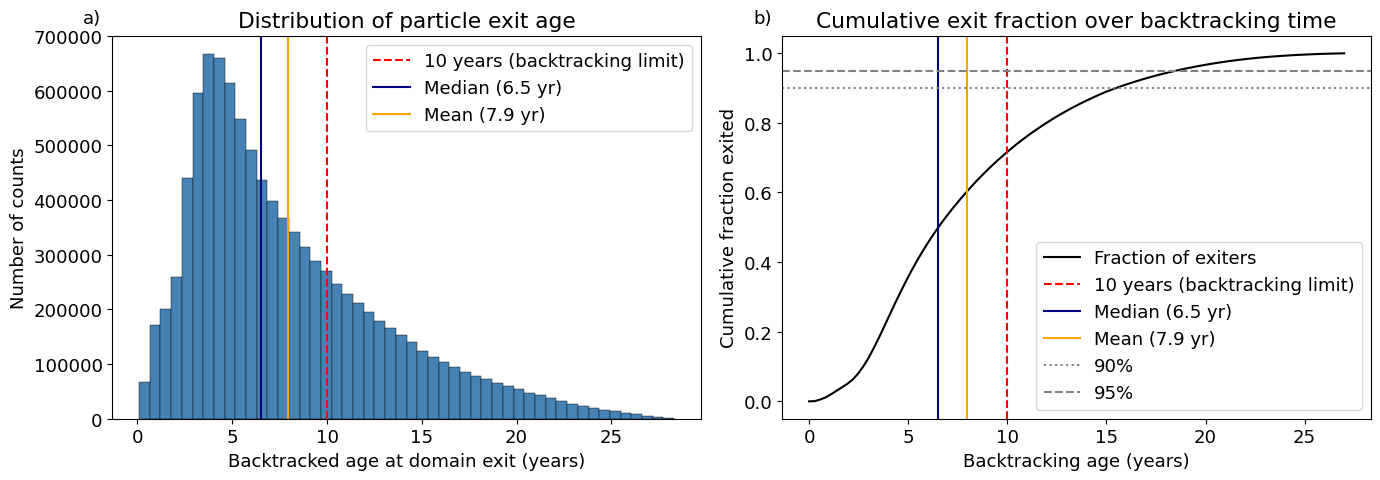

In [44]:
plt.rcParams.update({"font.size": 13})

median_exiters = np.median(age_values)
mean_exiters = age_values.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
weights = np.ones(len(age_values)) / n_total * 100
# --- LEFT: Histogram ---
axes[0].hist(age_values, bins=50, edgecolor="k", linewidth=0.3, color="steelblue")
axes[0].axvline(x=10, color="r", linestyle="--", label="10 years (backtracking limit)")
axes[0].axvline(
    x=median_exiters,
    color="navy",
    linestyle="-",
    label=f"Median ({median_exiters:.1f} yr)",
)
axes[0].axvline(
    x=mean_exiters, color="orange", linestyle="-", label=f"Mean ({mean_exiters:.1f} yr)"
)
axes[0].set_xlabel("Backtracked age at domain exit (years)")
axes[0].set_ylabel("Number of counts")
axes[0].set_title("Distribution of particle exit age")
axes[0].legend()

# --- RIGHT: Cumulative exit fraction ---
age_sorted = np.sort(age_values)
counts = np.searchsorted(age_sorted, age_bins, side="right")
fraction_exited_of_exiters = counts / n_exiters

axes[1].plot(
    age_bins, fraction_exited_of_exiters, color="k", label="Fraction of exiters"
)
axes[1].axvline(x=10, color="r", linestyle="--", label="10 years (backtracking limit)")
axes[1].axvline(
    x=median_exiters,
    color="navy",
    linestyle="-",
    label=f"Median ({median_exiters:.1f} yr)",
)
axes[1].axvline(
    x=mean_exiters, color="orange", linestyle="-", label=f"Mean ({mean_exiters:.1f} yr)"
)
axes[1].axhline(y=0.90, color="grey", linestyle=":", label="90%")
axes[1].axhline(y=0.95, color="grey", linestyle="--", label="95%")
axes[1].set_xlabel("Backtracking age (years)")
axes[1].set_ylabel("Cumulative fraction exited")
axes[1].set_title("Cumulative exit fraction over backtracking time")
axes[1].legend()

for ax, label in zip(axes, ["a)", "b)"]):
    ax.text(-0.05, 1.07, label, transform=ax.transAxes, va="top", ha="left")

plt.tight_layout()
# plt.savefig('S1.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure S3

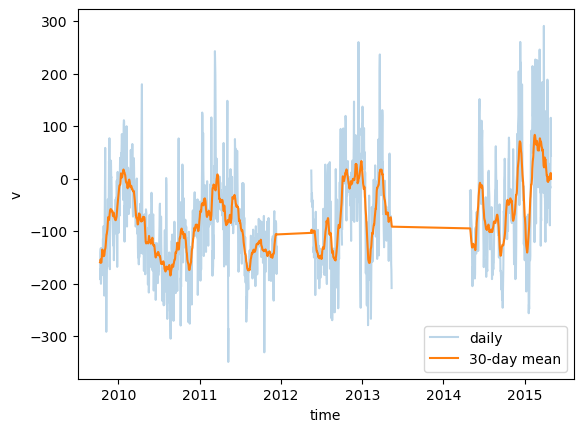

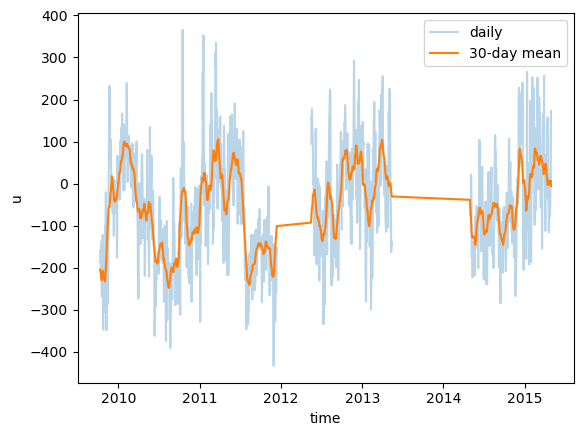

In [22]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"

ds_NWSG = xr.open_dataset(inpath + "ADCP/NWSG_extended.nc")

plt.rcParams.update({"font.size": 10})

v_depth = ds_NWSG.v.isel(depth=slice(60, None)).mean(dim="depth")
v_smooth = v_depth.rolling(time=30, center=True, min_periods=15).mean()
u_depth = ds_NWSG.u.isel(depth=slice(60, None)).mean(dim="depth")
u_smooth = u_depth.rolling(time=30, center=True, min_periods=15).mean()
v_monthly = v_depth.resample(time="MS").mean()  # 'MS' = month start

fig, ax = plt.subplots()
v_depth.plot(ax=ax, alpha=0.3, label="daily")
v_smooth.plot(ax=ax, label="30-day mean")
ax.legend()
# plt.ylim(-200,100)
plt.show()

fig, ax = plt.subplots()
u_depth.plot(ax=ax, alpha=0.3, label="daily")
u_smooth.plot(ax=ax, label="30-day mean")
ax.legend()
# plt.ylim(-200,100)
plt.show()

In [23]:
## import GLORYS12 data

inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
mesh_mask = xr.open_dataset(inpath + "mesh_masks/combined_mesh_mask.nc")
bathy = mesh_mask.hdept.isel(t=0)
land_mask = mesh_mask.tmaskutil.isel(t=0).where(mesh_mask.tmaskutil.isel(t=0) != 0)
lon, lat = mesh_mask.nav_lon, mesh_mask.nav_lat

ds_U = xr.open_mfdataset(inpath + "U_monthly/*.nc", combine="by_coords").vozocrtx
ds_V = xr.open_mfdataset(inpath + "V_monthly/*.nc", combine="by_coords").vomecrty

In [25]:
def select_data(data):
    north_sel = data.isel(y=slice(300, None), x=slice(300, None))
    return north_sel


U = select_data(ds_U)
V = select_data(ds_V)

In [26]:
# Set index on U (and V separately, as they live on different C-grid points)
U.xoak.set_index(["nav_lat", "nav_lon"], "sklearn_geo_balltree")
V.xoak.set_index(["nav_lat", "nav_lon"], "sklearn_geo_balltree")

In [27]:
# Single point — wrap as scalar DataArrays (0-dim)
target_lat = xr.DataArray(60.49)
target_lon = xr.DataArray(-4.56)

U_NWSG = U.xoak.sel(nav_lat=target_lat, nav_lon=target_lon)
V_NWSG = V.xoak.sel(nav_lat=target_lat, nav_lon=target_lon)

U_NWSG_ts = U_NWSG.sel(deptht=slice(605, 695)).isel(deptht=0).compute()
V_NWSG_ts = V_NWSG.sel(deptht=slice(605, 695)).isel(deptht=0).compute()

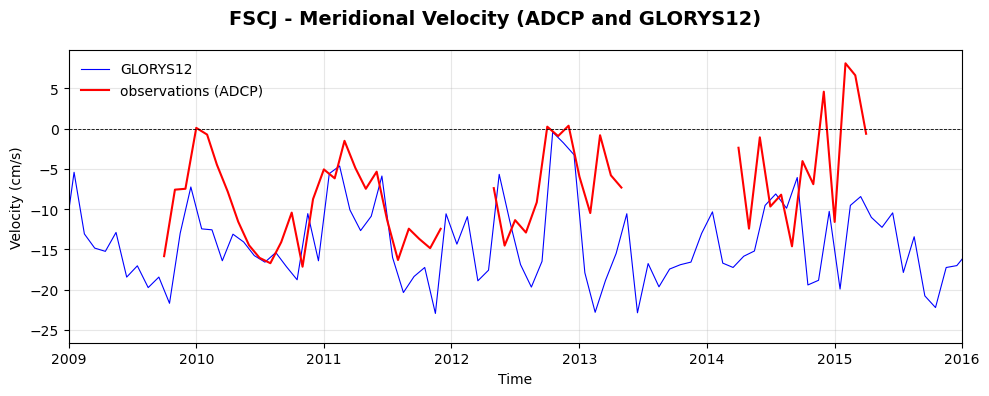

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))

(V_NWSG_ts * 100).plot(ax=ax, color="blue", alpha=1, linewidth=0.8, label="GLORYS12")
(v_monthly / 10).plot(ax=ax, color="red", linewidth=1.5, label="observations (ADCP)")

ax.set_xlim(pd.Timestamp("2009-01-01"), pd.Timestamp("2016-01-01"))
# ax.set_title('V velocity (North-South)', fontsize=12)
ax.set_xlabel("Time")
ax.set_ylabel("Velocity (cm/s)")
ax.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

fig.suptitle(
    "FSCJ - Meridional Velocity (ADCP and GLORYS12)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
# plt.savefig('FigS3_ADCP.png', dpi=300)
plt.show()

## Figure S4

In [6]:
Greenland_residence_times = xr.open_dataset(
    "netcdfs/Greenland_residence_times.nc"
).Greenland_residence_time_months
Lofoten_residence_times = xr.open_dataset(
    "netcdfs/Lofoten_residence_times.nc"
).Lofoten_residence_time_months

print(
    "percentage of particle crossing greenland sea =",
    Greenland_residence_times.trajectory.size / 14696179,
)

print(
    "percentage of particle crossing lofoten =",
    Lofoten_residence_times.trajectory.size / 14696179,
)

print(
    f"Greenland median residence: {float(np.median(Greenland_residence_times.values)):.1f} months"
)
print(
    f"Lofoten median residence: {float(np.median(Lofoten_residence_times.values)):.1f} months"
)

ds_transit_times_all = xr.open_dataset("netcdfs/transit_times_FSC_w_traj_number.nc")

percentage of particle crossing greenland sea = 0.3377614684742204
percentage of particle crossing lofoten = 0.41156146778016245
Greenland median residence: 5.6 months
Lofoten median residence: 10.1 months


In [8]:
ds_Svinoy_only_transit_times = ds_transit_times_all.Svinoy_only_transit_times
ds_N_only_transit_times = ds_transit_times_all.N_only_transit_times
ds_N_Svinoy_transit_times = ds_transit_times_all.N_Svinoy_transit_times

# convert to months
N_times = ds_N_only_transit_times * hours_to_months
Svinoy_times = ds_Svinoy_only_transit_times * hours_to_months
Overshoot_times = ds_N_Svinoy_transit_times * hours_to_months

Overshoot_times = Overshoot_times.where(Overshoot_times > -100, np.nan)

In [10]:
def bootstrap_median_ci(
    transit_times, n_resamples=1000, confidence=0.95, subsample=10000
):
    # with hundreds of thousands of particles, subsampling is fine
    vals = transit_times.values
    if len(vals) > subsample:
        vals = np.random.choice(vals, size=subsample, replace=False)
    data = (vals,)
    res = bootstrap(
        data, np.nanmedian, n_resamples=n_resamples, confidence_level=confidence
    )
    return res.confidence_interval.low, res.confidence_interval.high


ds_Svinoy_only_transit_times = ds_transit_times_all.Svinoy_only_transit_times
ds_N_only_transit_times = ds_transit_times_all.N_only_transit_times
ds_N_Svinoy_transit_times = ds_transit_times_all.N_Svinoy_transit_times

datasets = {
    "Svinøy section only": ds_Svinoy_only_transit_times,
    "N section only": ds_N_only_transit_times,
    "Overshooting (N + Svinøy)": ds_N_Svinoy_transit_times,
}

for name, ds in datasets.items():
    times = ds * hours_to_months
    low, high = bootstrap_median_ci(times)
    median = np.nanmedian(times.values)
    print(f"--- {name} ---")
    print(f"  n trajectories: {len(times.values)}")
    print(f"  Median:         {median:.1f} months")
    print(f"  95% CI:         [{low:.1f}, {high:.1f}] months")
    print(f"  Uncertainty:    ±{(high - low) / 2:.2f} months")
    print()

--- Svinøy section only ---
  n trajectories: 848126
  Median:         -13.3 months
  95% CI:         [nan, nan] months
  Uncertainty:    ±nan months

--- N section only ---
  n trajectories: 7250095
  Median:         -9.1 months
  95% CI:         [nan, nan] months
  Uncertainty:    ±nan months

--- Overshooting (N + Svinøy) ---
  n trajectories: 6029736
  Median:         -58.2 months
  95% CI:         [-59.2, -56.2] months
  Uncertainty:    ±1.48 months



In [14]:
overflow_trajectory_size = 14696179
transit_FSC_to_Greenland = xr.open_dataset(
    "netcdfs/transit_FSC_to_Greenland.nc"
).transit_FSC_to_Greenland_years
heatmap_FSC_to_Greenland = xr.open_dataset(
    "netcdfs/heatmap_FSC_to_Greenland.nc"
).heatmap_FSC_to_Greenland

heatmap_FSC_to_Greenland_weighted = xr.open_dataset(
    "netcdfs/heatmap_FSC_to_Greenland.nc"
).heatmap_FSC_to_Greenland_weighted

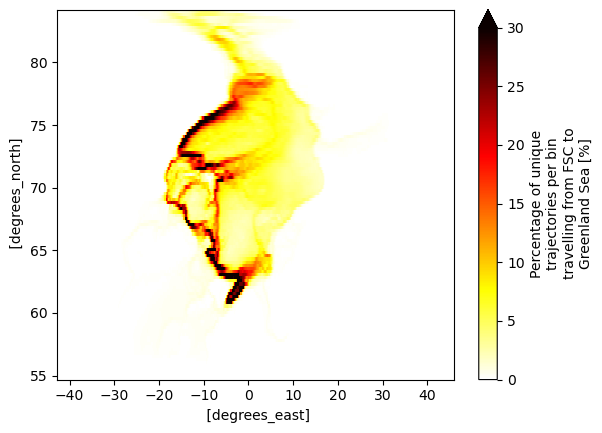

In [15]:
heatmap_FSC_to_Greenland.plot(cmap="hot_r", vmin=0, vmax=30)

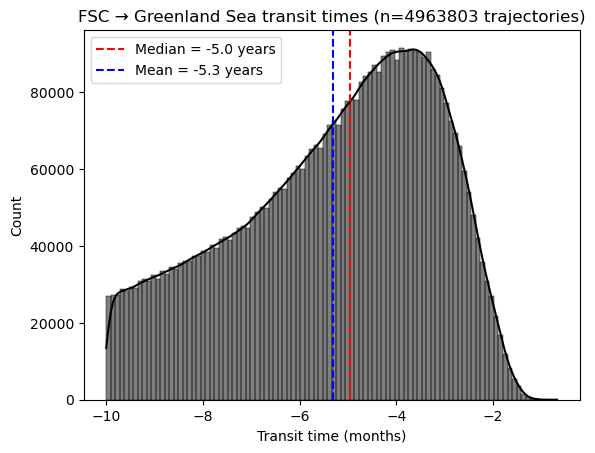

In [16]:
transit_FSC_to_Greenland = transit_FSC_to_Greenland

sns.histplot(transit_FSC_to_Greenland, bins=100, color="black", alpha=0.5, kde=True)
plt.xlabel("Transit time from FSC to first entry into Greenland Sea (years)")
plt.axvline(
    x=np.median(transit_FSC_to_Greenland),
    color="red",
    linestyle="--",
    label=f"Median = {np.median(transit_FSC_to_Greenland):.1f} years",
)
plt.axvline(
    x=np.mean(transit_FSC_to_Greenland),
    color="blue",
    linestyle="--",
    label=f"Mean = {np.mean(transit_FSC_to_Greenland):.1f} years",
)
plt.legend()
plt.title(
    f"FSC → Greenland Sea transit times (n={len(transit_FSC_to_Greenland)} trajectories)"
)
plt.xlabel("Transit time (months)")
plt.ylabel("Count")
plt.show()

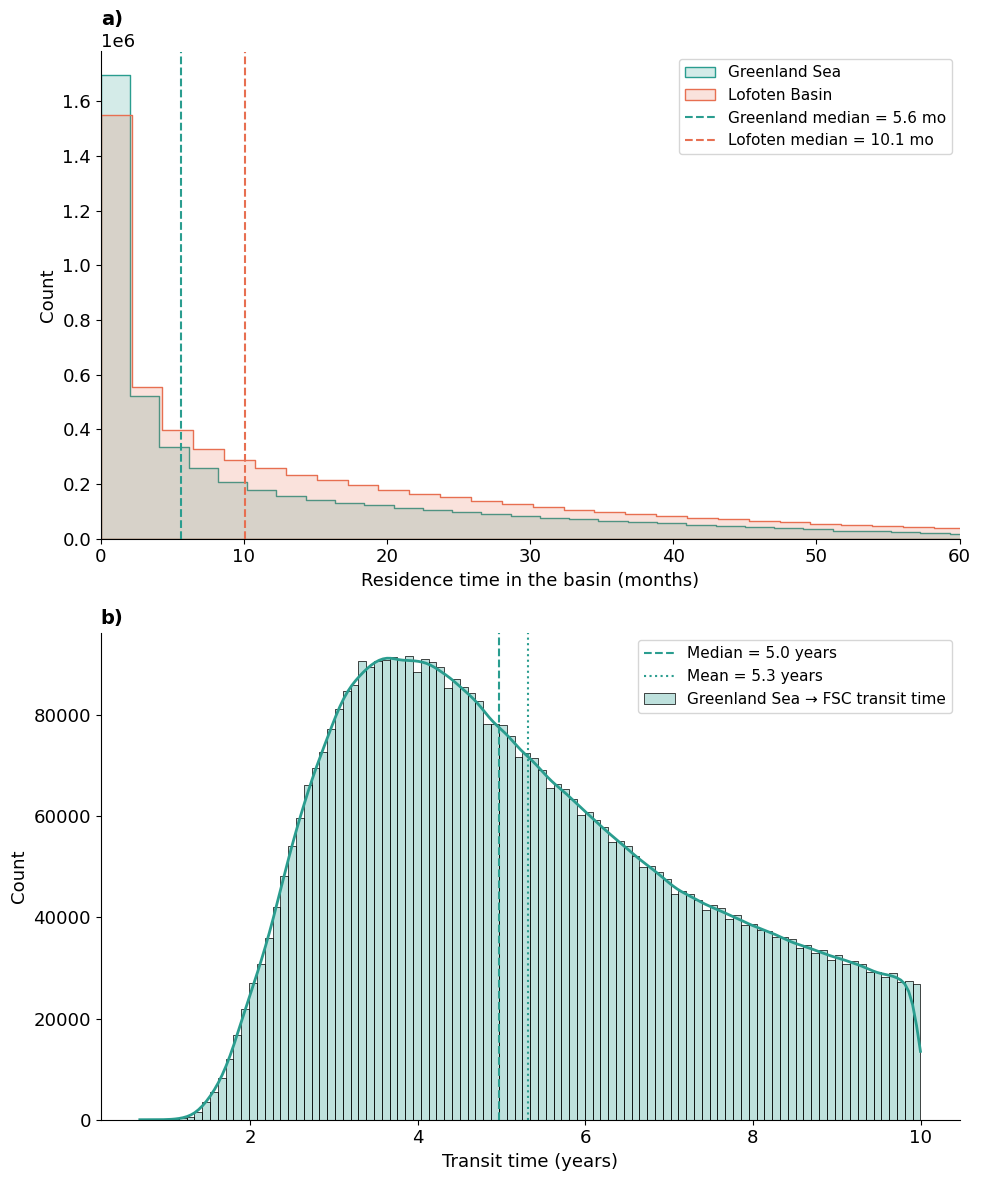

In [18]:
plt.rcParams.update({"font.size": 13})

greenland_color = "#2a9d8f"  # teal
lofoten_color = "#e76f51"  # coral

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# ---- Panel a): Residence times ----
ax = axes[0]
sns.histplot(
    Greenland_residence_times,
    bins=50,
    stat="count",
    element="step",
    fill=True,
    alpha=0.2,
    color=greenland_color,
    line_kws={"linewidth": 2},
    label="Greenland Sea",
    ax=ax,
)
sns.histplot(
    Lofoten_residence_times,
    bins=50,
    stat="count",
    element="step",
    fill=True,
    alpha=0.2,
    color=lofoten_color,
    line_kws={"linewidth": 2},
    label="Lofoten Basin",
    ax=ax,
)

for val, color, label in [
    (
        np.median(Greenland_residence_times),
        greenland_color,
        f"Greenland median = {np.median(Greenland_residence_times):.1f} mo",
    ),
    (
        np.median(Lofoten_residence_times),
        lofoten_color,
        f"Lofoten median = {np.median(Lofoten_residence_times):.1f} mo",
    ),
]:
    ax.axvline(x=val, color=color, linestyle="--", linewidth=1.5, label=label)

ax.set_xlabel("Residence time in the basin (months)", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.set_xlim(0, 60)
ax.legend(frameon=True, fontsize=11)
ax.set_title("a)", fontsize=14, fontweight="bold", loc="left")
sns.despine(ax=ax)

# ---- Panel b): Transit times FSC → Greenland Sea ----
ax = axes[1]
sns.histplot(
    np.abs(transit_FSC_to_Greenland),
    bins=100,
    color=greenland_color,
    alpha=0.3,
    kde=True,
    line_kws={"linewidth": 2},
    label="Greenland Sea → FSC transit time",
    ax=ax,
)

ax.axvline(
    x=np.nanmedian(np.abs(transit_FSC_to_Greenland)),
    color=greenland_color,
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {np.nanmedian(np.abs(transit_FSC_to_Greenland)):.1f} years",
)
ax.axvline(
    x=np.nanmean(np.abs(transit_FSC_to_Greenland)),
    color=greenland_color,
    linestyle=":",
    linewidth=1.5,
    label=f"Mean = {np.nanmean(np.abs(transit_FSC_to_Greenland)):.1f} years",
)

ax.set_xlabel("Transit time (years)", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.legend(frameon=True, fontsize=11)
ax.set_title("b)", fontsize=14, fontweight="bold", loc="left")
sns.despine(ax=ax)

plt.tight_layout()
# plt.savefig('S4.png', dpi=300, bbox_inches='tight')
plt.show()